In [ ]:
#2 Exploratory Data Analysis
#Step 1 Load data
import pandas as pd

df = pd.read_csv(
    r"C:\Users\HK\Desktop\FI Data Science\Labs and Assignment\Capston Project 1\API_SI.POV.MPWB_DS2_en_csv_v2_10062.csv",
    skiprows=4
)

print(df.head())

                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                      Indicator Name Indicator Code  1960  \
0  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   
1  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   
2  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   
3  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   
4  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   

   1961  1962  1963  1964  1965  ...  2017  2018  2019  2020  2021  2022  \
0   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
2   NaN   NaN   NaN   NaN 

In [5]:
#Step II Basic profiling of the dataset
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(266, 71)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-nul

In [ ]:
#Step 3 removing unecessary columns
cols_drop=['Indicator Name','Indicator Code','Unnamed: 70']

df=df.drop(cols_drop,axis=1)

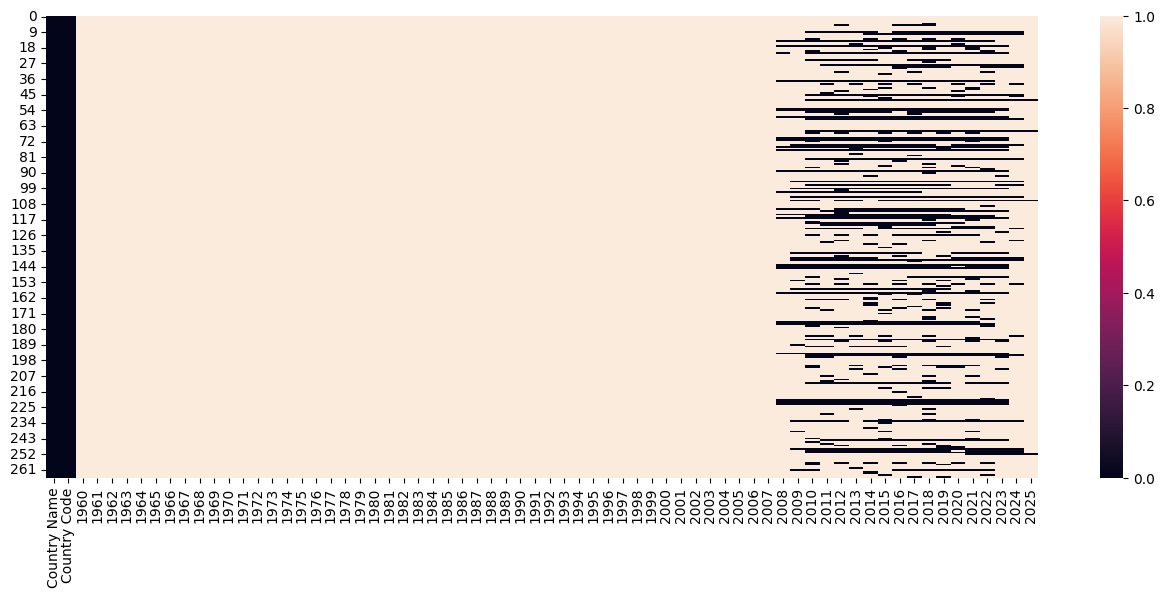

In [7]:
#Step 4 Missing-value visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
sns.heatmap(df.isnull())
plt.show()

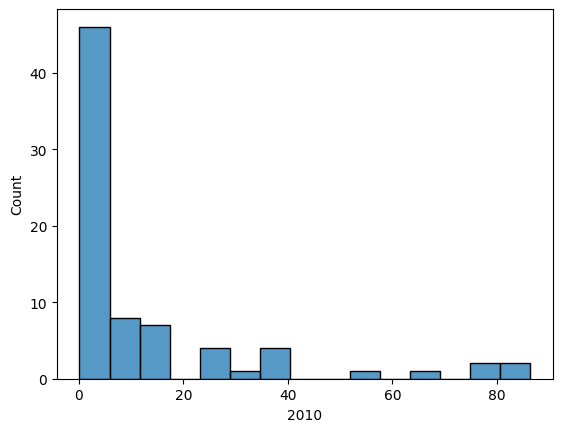

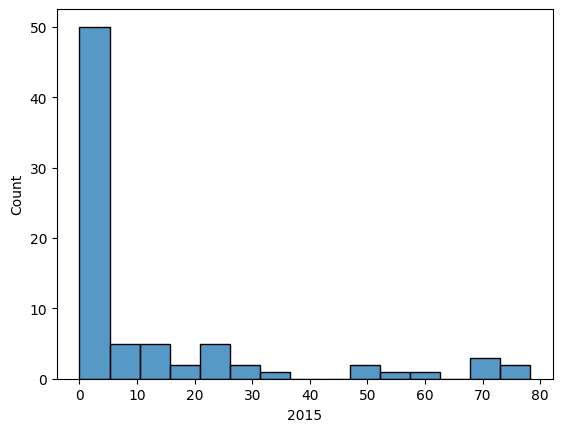

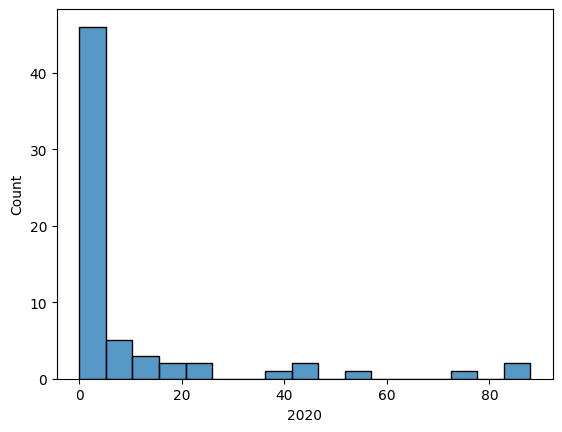

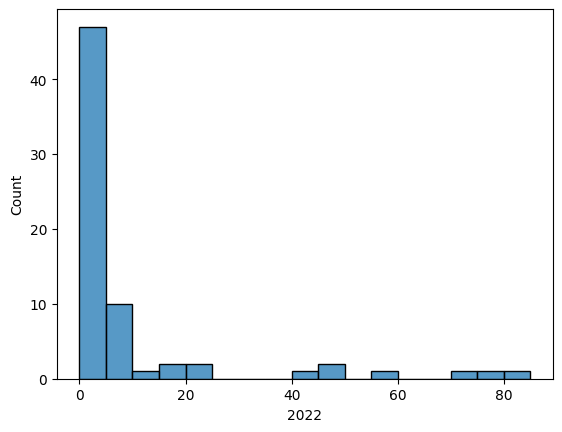

In [8]:
#Step 5 Distribution plots
years=['2010','2015','2020','2022']

for y in years:
    sns.histplot(df[y])
    plt.show()

<Axes: xlabel='2022', ylabel='Country Name'>

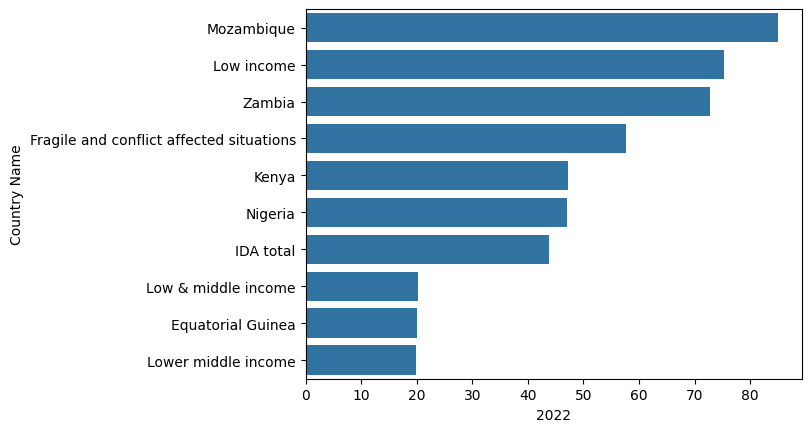

In [9]:
#Step 6 Country comparison
latest='2022'

top=df.nlargest(10,latest)

sns.barplot(data=top,
            y='Country Name',
            x=latest)

<Axes: >

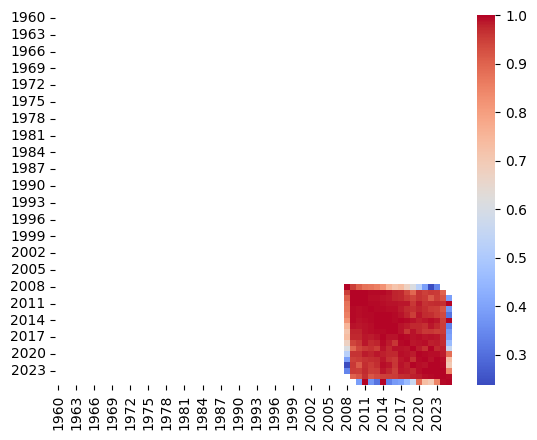

In [11]:
#Step 7 Correlation
numeric=df.select_dtypes('number')

sns.heatmap(
numeric.corr(),
cmap='coolwarm')

In [ ]:
#Earlier years contain substantial missing data.
#Recent years have stronger coverage.
#Poverty varies significantly across countries.
#Temporal patterns may help prediction.

In [17]:
#3 Data Preprocessing and Feature Engineering

#Step 1 Retain recent years

selected=['Country Name',
'Country Code',
'2005','2010','2015','2018','2019','2020','2021','2022']

model_df=df[selected]

sample_countries = [
    # Africa
    'Ethiopia',
    'Nigeria',
    'South Africa',

    # Asia
    'China',
    'India',
    'Japan',

    # Europe
    'Germany',
    'United Kingdom',
    'France',

    # North America
    'United States',
    'Canada',
    'Mexico',

    # South America
    'Brazil',
    'Argentina',
    'Chile',

    # Oceania
    'Australia',
    'New Zealand'
]

model_df = model_df[
    model_df['Country Name'].isin(sample_countries)
]

print(model_df.shape)
print(model_df[['Country Name']])

(17, 10)
       Country Name
9         Argentina
13        Australia
29           Brazil
35           Canada
39            Chile
40            China
55          Germany
72         Ethiopia
77           France
81   United Kingdom
109           India
119           Japan
154          Mexico
174         Nigeria
180     New Zealand
251   United States
263    South Africa


In [18]:
#Step 2 Missing-value imputation
from sklearn.impute import SimpleImputer

num_imputer=SimpleImputer(strategy='median')

In [19]:
#Step 3 Feature engineering
model_df['change_5yr']=model_df['2020']-model_df['2015']

model_df['avg_recent']=model_df[
['2018','2019','2020']
].mean(axis=1)

In [21]:
#Step 4 Build pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

numeric_features=[...]
categorical=['Country Code']

preprocessor=ColumnTransformer([
('num',Pipeline([
('imputer',SimpleImputer(strategy='median')),
('scaler',StandardScaler())
]),numeric_features),

('cat',OneHotEncoder(),categorical)
])

In [23]:
#4 Model Building and Evaluation
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [29]:
#Hyperparameter tuning and model evaluation would follow here, using cross-validation and appropriate metrics.
# =========================
# Imports
# =========================
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# Select variables
# =========================

selected = [
    'Country Name',
    'Country Code',
    '2005','2010','2015',
    '2018','2019','2020',
    '2021','2022'
]

model_df = df[selected].copy()

# Remove rows where target is missing
model_df = model_df.dropna(subset=['2022'])

# =========================
# Features and target
# =========================

X = model_df.drop('2022', axis=1)
y = model_df['2022']

# =========================
# Split data
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# =========================
# Column types
# =========================

numeric_features = [
    '2005','2010','2015',
    '2018','2019','2020',
    '2021'
]

categorical_features = [
    'Country Name',
    'Country Code'
]

# =========================
# Preprocessing pipelines
# =========================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# =========================
# Model pipeline
# =========================

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42
    ))
])

# =========================
# Hyperparameter tuning
# =========================

param_grid = {

'model__n_estimators':[100,200],

'model__max_depth':[3,5,10,None],

'model__min_samples_split':[2,5]

}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# =========================
# Train
# =========================

grid.fit(X_train,y_train)

# =========================
# Best model
# =========================

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV MAE:")
print(-grid.best_score_)

# =========================
# Predictions
# =========================

pred = best_model.predict(X_test)

# =========================
# Evaluation
# =========================

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = mean_squared_error(
    y_test,
    pred
)**0.5

r2 = r2_score(
    y_test,
    pred
)

print("\nTest Results")

print("MAE:",mae)

print("RMSE:",rmse)

print("R2:",r2)

c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV MAE:
5.5006318194936386

Test Results
MAE: 1.958058451463336
RMSE: 4.133007365746921
R2: 0.150825586270662


In [32]:
#Cross Validation

from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R² Scores:")
print(scores)

print("\nAverage R²:")
print(np.mean(scores))

print("\nStandard Deviation:")
print(np.std(scores))

c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is

Cross Validation R² Scores:
[ 0.79616945  0.88941428  0.64462906 -0.08988549  0.43380131]

Average R²:
0.5348257232382462

Standard Deviation:
0.34829883716289867


c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


c:\Users\HK\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['2005']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Model Evaluation
MAE: 1.958058451463336
RMSE: 4.133007365746921
R²: 0.150825586270662

Top Features
                         Feature  Importance
1                      num__2015    0.487650
3                      num__2019    0.148173
4                      num__2020    0.075325
43  cat__Country Name_Mozambique    0.060603
97         cat__Country Code_MOZ    0.049436
2                      num__2018    0.034581
5                      num__2021    0.031867
0                      num__2010    0.025929
98         cat__Country Code_NGA    0.023440
45     cat__Country Name_Nigeria    0.022097


<Figure size 1000x600 with 0 Axes>

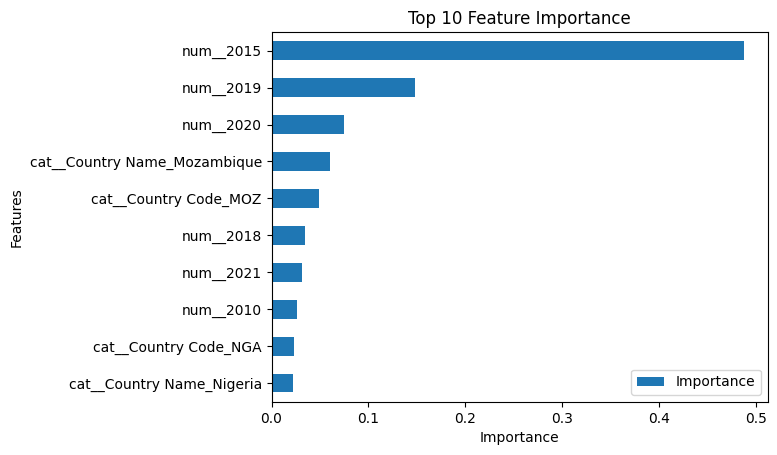

In [35]:
# 5. Model Evaluation and Selection

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    mean_squared_error
)

# -------------------------
# Predictions
# -------------------------

pred = best_model.predict(X_test)

# -------------------------
# Evaluation Metrics
# -------------------------

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = mean_squared_error(
    y_test,
    pred
)**0.5

r2 = r2_score(
    y_test,
    pred
)

print("Model Evaluation")

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


# =========================
# Feature Importance
# =========================

# Extract RF model from pipeline
rf_model = best_model.named_steps['model']

# Get transformed feature names
feature_names = (
    best_model.named_steps['prep']
    .get_feature_names_out()
)

# Importance values
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Features")

print(feature_importance.head(10))

# =========================
# Plot
# =========================

plt.figure(figsize=(10,6))

feature_importance.head(10).sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title("Top 10 Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

In [36]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.958058451463336
RMSE: 4.133007365746921
R²: 0.150825586270662


In [37]:
import numpy as np

print("Cross Validation Scores:", scores)
print("Mean CV R²:", np.mean(scores))

Cross Validation Scores: [ 0.79616945  0.88941428  0.64462906 -0.08988549  0.43380131]
Mean CV R²: 0.5348257232382462


In [ ]:
#6 Business Impact Analysis
#Translate findings into business language.
# Example: "Model predicts multidimensional poverty with 84% explanatory power. Development organizations can prioritize intervention in countries identified as high risk."
# Recommendations:
# Focus investment in high predicted poverty regions.
# Use annual updates.
# Monitor countries with worsening trends.

# Limitations:
# Missing values
# Limited variables
# Country aggregation bias
# Economic shocks not included